# Dataset & Split Overview

Read-only inspection notebook, no training. Answers three questions for every classification/regression task in `baseline_0` / `exp_1`:
1. What columns does each dataset have?
2. What is the target column?
3. How is the train/test split done?

In [1]:
from pathlib import Path
import polars as pl
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold

SNAKE_DIR = Path("/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake")
OUT = SNAKE_DIR / "outputs/cpcnn/mad_featselect"
ANNOT = SNAKE_DIR / "inputs/annotations"


## 1. Feature datasets

Two feature tables. `agg.parquet` is `mad_featselect.parquet` mean-aggregated per compound (see `classifier/aggregate_profiles.py`) — same underlying data, two forms.

In [2]:
mad_featselect = pl.read_parquet(OUT / "profiles/mad_featselect.parquet")
meta_cols = [c for c in mad_featselect.columns if c.startswith("Metadata")]
feat_cols = [c for c in mad_featselect.columns if not c.startswith("Metadata")]

print(f"mad_featselect.parquet -- shape {mad_featselect.shape}  (used for REGRESSION, one row per well)")
print(f"  {len(meta_cols)} metadata columns:")
for c in meta_cols:
    print(f"    {c}")
print(f"  {len(feat_cols)} feature columns (CP-CNN embedding), e.g.: {feat_cols[:5]} ... {feat_cols[-2:]}")


mad_featselect.parquet -- shape (21456, 693)  (used for REGRESSION, one row per well)
  26 metadata columns:
    Metadata_Plate
    Metadata_Well
    Metadata_X
    Metadata_Y
    Metadata_well_id
    Metadata_source
    Metadata_Concentration
    Metadata_Compound
    Metadata_compound_target
    Metadata_compound_pathway
    Metadata_compound_research_area
    Metadata_compound_clinical_information
    Metadata_row
    Metadata_col
    Metadata_mtt_lumi
    Metadata_ldh_abs_signal
    Metadata_ldh_abs_background
    Metadata_ldh_abs
    Metadata_mtt_normalized
    Metadata_ldh_normalized
    Metadata_mtt_ridge_norm
    Metadata_ldh_ridge_norm
    Metadata_OASIS_ID
    Metadata_Perturbation
    Metadata_Log10Conc
    Metadata_Count_Cells
  667 feature columns (CP-CNN embedding), e.g.: ['f_001', 'f_002', 'f_003', 'f_004', 'f_005'] ... ['f_671', 'f_672']


In [3]:
agg = pl.read_parquet(OUT / "aggregated_profiles/agg.parquet")
agg_meta_cols = [c for c in agg.columns if c.startswith("Metadata")]
agg_feat_cols = [c for c in agg.columns if not c.startswith("Metadata")]

print(f"agg.parquet -- shape {agg.shape}  (used for CLASSIFICATION, one row per compound per AggType)")
print(f"  {len(agg_meta_cols)} metadata columns: {agg_meta_cols}")
print(f"  {len(agg_feat_cols)} feature columns: {agg_feat_cols[:5]} ... {agg_feat_cols[-2:]}")
print(f"  ('Cell_Count' is included and gets aggregated like any other feature -- it's the Cellcount_baseline's single input column)")
print()
print("Metadata_AggType values:", agg["Metadata_AggType"].unique().to_list())
print("agg.parquet has NO target column itself -- targets come from joining in one of the 4 label files below on Metadata_OASIS_ID.")


agg.parquet -- shape (2904, 670)  (used for CLASSIFICATION, one row per compound per AggType)
  2 metadata columns: ['Metadata_OASIS_ID', 'Metadata_AggType']
  668 feature columns: ['f_001', 'f_002', 'f_003', 'f_004', 'f_005'] ... ['f_672', 'Cell_Count']
  ('Cell_Count' is included and gets aggregated like any other feature -- it's the Cellcount_baseline's single input column)

Metadata_AggType values: ['allpodcc', 'allpod', 'all']
agg.parquet has NO target column itself -- targets come from joining in one of the 4 label files below on Metadata_OASIS_ID.


## 2. Classification label datasets

Every non-`OASIS_ID` column in these 4 files is itself a separate binary target -- one classifier is trained per column, per `Metadata_AggType`.

In [4]:
LABEL_FILES = {
    "axiom": OUT / "curves/axiom_hits.parquet",
    "toxcast_cytotox": ANNOT / "toxcast_cytotox_binary.parquet",
    "toxcast_cellfree": ANNOT / "toxcast_cellfree_binary.parquet",
    "toxcast_cellbased": ANNOT / "toxcast_cellbased_binary.parquet",
}

for name, path in LABEL_FILES.items():
    df = pl.read_parquet(path)
    targets = [c for c in df.columns if c != "OASIS_ID"]
    print(f"{name}: shape {df.shape}, {len(targets)} target columns")
    if len(targets) <= 10:
        print(f"  targets: {targets}")
    else:
        print(f"  targets (first 10 of {len(targets)}): {targets[:10]}")
    print()


axiom: shape (1086, 4), 3 target columns
  targets: ['MTT', 'LDH', 'cell_count']

toxcast_cytotox: shape (963, 39), 38 target columns
  targets (first 10 of 38): ['cell_type__umbilical_vein_endothelium_and_peripheral_blood_mononuclear_cells', 'cell_type__HepG2', 'cell_type__HEK293T', 'cell_type__HEK293', 'cell_type__HeLa', 'cell_type__HCT116', 'cell_type__ME-180', 'cell_type__H295R', 'cell_type__MDA-kb2', 'cell_type__hNP1']

toxcast_cellfree: shape (371, 73), 72 target columns
  targets (first 10 of 72): ['NVS_ADME_hCYP19A1', 'NVS_ADME_hCYP1A1', 'NVS_ADME_hCYP1A2', 'NVS_ADME_hCYP2A6', 'NVS_ADME_hCYP2B6', 'NVS_ADME_hCYP2C19', 'NVS_ADME_hCYP2C9', 'NVS_ADME_hCYP2D6', 'NVS_ADME_hCYP2J2', 'NVS_ADME_hCYP3A4']

toxcast_cellbased: shape (963, 293), 292 target columns
  targets (first 10 of 292): ['ACEA_ER_80hr', 'APR_HepG2_CellCycleArrest_24hr', 'APR_HepG2_CellLoss_24hr', 'APR_HepG2_MicrotubuleCSK_24hr', 'APR_HepG2_MitoMass_24hr', 'APR_HepG2_MitoMembPot_24hr', 'APR_HepG2_MitoticArrest_24hr', '

## 3. Regression -- target column and split

Target: `Metadata_mtt_ridge_norm` or `Metadata_ldh_ridge_norm`, columns already inside `mad_featselect.parquet`. Every well is one training sample (no aggregation).

Split: `GroupShuffleSplit(n_splits=10, test_size=0.2, random_state=42)`, grouped by `Metadata_Compound` -- a compound's wells (all concentrations, all replicates) always land entirely in train OR entirely in test, never split across both. Repeated 10x with different random train/test compound partitions (not a k-fold partition of the whole dataset -- test sets can overlap across the 10 splits).

In [5]:
dat = mad_featselect.drop_nulls(subset=["Metadata_OASIS_ID"]).filter(pl.col("Metadata_Perturbation") != "DMSO_0.0").to_pandas()
groups = dat["Metadata_Compound"]

gss = GroupShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
print(f"{dat.shape[0]} wells across {groups.nunique()} compounds\n")
print(f"{'split':>5} {'train wells':>12} {'test wells':>11} {'train cmpds':>12} {'test cmpds':>11} {'cmpd overlap':>13}")
for i, (train_idx, test_idx) in enumerate(gss.split(dat, groups=groups)):
    train_cmpds = set(groups.iloc[train_idx])
    test_cmpds = set(groups.iloc[test_idx])
    print(f"{i:>5} {len(train_idx):>12} {len(test_idx):>11} {len(train_cmpds):>12} {len(test_cmpds):>11} {len(train_cmpds & test_cmpds):>13}")


14769 wells across 966 compounds

split  train wells  test wells  train cmpds  test cmpds  cmpd overlap
    0        11814        2955          772         194             0
    1        11779        2990          772         194             0
    2        11822        2947          772         194             0
    3        11787        2982          772         194             0
    4        11803        2966          772         194             0
    5        11795        2974          772         194             0
    6        11795        2974          772         194             0
    7        11779        2990          772         194             0
    8        11788        2981          772         194             0
    9        11821        2948          772         194             0


## 4. Classification -- target column and split

Target: one column from a label file (e.g. `MTT` from `axiom_hits.parquet`), joined onto `agg.parquet` on `Metadata_OASIS_ID`. One row per compound (already aggregated across wells).

Split: `StratifiedKFold(n_splits=5)` -- ordinary 5-fold CV (not grouped; each row is already one compound, so no within-compound leakage risk), stratified to preserve class balance in every fold. Run independently per `(label, Metadata_AggType)` combination, and per `Model_type` (`Actual` / `Random_baseline` / `Cellcount_baseline`).

In [6]:
axiom_hits = pl.read_parquet(LABEL_FILES["axiom"]).rename({"OASIS_ID": "Metadata_OASIS_ID"})
example = agg.join(axiom_hits, on="Metadata_OASIS_ID", how="left").filter(
    (pl.col("Metadata_AggType") == "all") & pl.col("MTT").is_not_null()
).to_pandas()

X = example.drop(columns=[c for c in example.columns if c.startswith("Metadata") or c in ["MTT", "LDH", "cell_count"]])
y = example["MTT"].astype(int)

print(f"Example: label=MTT, AggType=all -- {len(y)} compounds ({(y==0).sum()} class-0, {(y==1).sum()} class-1)\n")

skf = StratifiedKFold(n_splits=5)
print(f"{'fold':>5} {'train n':>8} {'test n':>7} {'test class-0':>13} {'test class-1':>13}")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    y_test = y.iloc[test_idx]
    print(f"{i:>5} {len(train_idx):>8} {len(test_idx):>7} {(y_test==0).sum():>13} {(y_test==1).sum():>13}")


Example: label=MTT, AggType=all -- 967 compounds (589 class-0, 378 class-1)

 fold  train n  test n  test class-0  test class-1
    0      773     194           118            76
    1      773     194           118            76
    2      774     193           118            75
    3      774     193           118            75
    4      774     193           117            76


## 5. Summary -- one row per task

In [7]:
import pandas as pd

summary = pd.DataFrame([
    {"Task": "Regression: MTT",  "Feature dataset": "mad_featselect.parquet (well-level)", "Target column": "Metadata_mtt_ridge_norm", "Split": "GroupShuffleSplit(10, test_size=0.2) grouped by Metadata_Compound"},
    {"Task": "Regression: LDH",  "Feature dataset": "mad_featselect.parquet (well-level)", "Target column": "Metadata_ldh_ridge_norm", "Split": "GroupShuffleSplit(10, test_size=0.2) grouped by Metadata_Compound"},
    {"Task": "Classification: axiom",             "Feature dataset": "agg.parquet (compound-level)", "Target column": "MTT / LDH / cell_count  (axiom_hits.parquet)", "Split": "StratifiedKFold(5), per label x AggType"},
    {"Task": "Classification: toxcast_cytotox",   "Feature dataset": "agg.parquet (compound-level)", "Target column": "38 cytotox columns  (toxcast_cytotox_binary.parquet)", "Split": "StratifiedKFold(5), per label x AggType"},
    {"Task": "Classification: toxcast_cellfree",  "Feature dataset": "agg.parquet (compound-level)", "Target column": "72 cellfree assay columns  (toxcast_cellfree_binary.parquet)", "Split": "StratifiedKFold(5), per label x AggType"},
    {"Task": "Classification: toxcast_cellbased", "Feature dataset": "agg.parquet (compound-level)", "Target column": "292 cellbased assay columns  (toxcast_cellbased_binary.parquet)", "Split": "StratifiedKFold(5), per label x AggType"},
    # NOTE: these are raw column counts in each label file. Not every label is actually trained --
    # process_label_and_agg (classify.py) skips any (label, AggType) combo with fewer than
    # n_splits=5 samples in either class, so the trained/reported count is lower (see cell 5 output above).
])
summary


,Task,Feature dataset,Target column,Split
0,Regression: MTT,mad_featselect.parquet (well-level),Metadata_mtt_ridge_norm,"GroupShuffleSplit(10, test_size=0.2) grouped b..."
1,Regression: LDH,mad_featselect.parquet (well-level),Metadata_ldh_ridge_norm,"GroupShuffleSplit(10, test_size=0.2) grouped b..."
2,Classification: axiom,agg.parquet (compound-level),MTT / LDH / cell_count (axiom_hits.parquet),"StratifiedKFold(5), per label x AggType"
3,Classification: toxcast_cytotox,agg.parquet (compound-level),38 cytotox columns (toxcast_cytotox_binary.pa...,"StratifiedKFold(5), per label x AggType"
4,Classification: toxcast_cellfree,agg.parquet (compound-level),72 cellfree assay columns (toxcast_cellfree_b...,"StratifiedKFold(5), per label x AggType"
5,Classification: toxcast_cellbased,agg.parquet (compound-level),292 cellbased assay columns (toxcast_cellbase...,"StratifiedKFold(5), per label x AggType"


## 6. Feature selection funnel -- raw.parquet to mad_featselect.parquet

Two separate steps remove features before modeling:
1. `stats.select_variant_features` (`raw.parquet` -> `variant_feats.parquet`): drops any feature with `mad == 0` or `abs_coef_var <= 1e-3` among DMSO wells, on **any** plate.
2. `select_features` (`mad.parquet` -> `mad_featselect.parquet`): drops features via three pycytominer filters in sequence -- `variance_threshold`, a magnitude filter (`abs value > outlier_feat_thresh`, 1e7 for `cpcnn.json`), then `correlation_threshold` on whatever remains.

`mad_normalize` itself (`variant_feats.parquet` -> `mad.parquet`) only rescales values -- it does not remove any features, so it's skipped in the funnel below.

In [8]:
import pandas as pd
from pycytominer.operations import correlation_threshold, variance_threshold


def find_feat_cols(cols):
    return [c for c in cols if not c.startswith("Metadata")]


RAW = Path("/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/1_snakemake/inputs/profiles/cpcnn/raw.parquet")

raw_feat = [c for c in pl.read_parquet(RAW, n_rows=1).columns if not c.startswith("Metadata")]
variant_feat = [c for c in pl.read_parquet(OUT / "profiles/variant_feats.parquet", n_rows=1).columns if not c.startswith("Metadata")]

# Recompute select_features' internal 3-way breakdown (it only logs this, doesn't save it)
mad_df = pd.read_parquet(OUT / "profiles/mad.parquet")
feat_thresh = 10_000_000  # cpcnn.json's outlier_feat_thresh

f0 = find_feat_cols(mad_df.columns)
low_variance = variance_threshold(mad_df, f0)
f1 = [f for f in f0 if f not in low_variance]

too_large = [f for f in f1 if (mad_df[f].abs() > feat_thresh).any()]
f2 = [f for f in f1 if f not in too_large]

high_corr = correlation_threshold(mad_df, f2)
f3 = [f for f in f2 if f not in high_corr]

funnel = pd.DataFrame([
    {"Stage": "raw.parquet", "n_features": len(raw_feat), "Dropped this step": 0, "Reason": "--"},
    {"Stage": "variant_feats.parquet", "n_features": len(variant_feat), "Dropped this step": len(raw_feat) - len(variant_feat), "Reason": "degenerate in DMSO (mad==0 or coef_var<=1e-3)"},
    {"Stage": "after variance_threshold", "n_features": len(f1), "Dropped this step": len(low_variance), "Reason": "low variance"},
    {"Stage": "after magnitude filter", "n_features": len(f2), "Dropped this step": len(too_large), "Reason": f"abs value > {feat_thresh:,}"},
    {"Stage": "mad_featselect.parquet", "n_features": len(f3), "Dropped this step": len(high_corr), "Reason": "correlation_threshold"},
])
funnel


,Stage,n_features,Dropped this step,Reason
0,raw.parquet,672,0,--
1,variant_feats.parquet,670,2,degenerate in DMSO (mad==0 or coef_var<=1e-3)
2,after variance_threshold,670,0,low variance
3,after magnitude filter,670,0,"abs value > 10,000,000"
4,mad_featselect.parquet,667,3,correlation_threshold


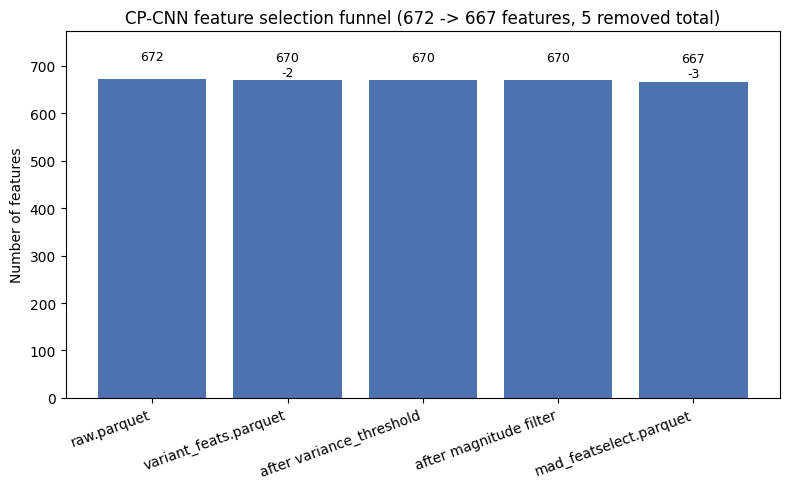

Only 5 of 672 features removed (0.7%) -- CP-CNN embedding dimensions are already fairly non-redundant/non-degenerate; most reduction work in this pipeline happens via MAD normalization + outlier handling, not feature count reduction.


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4c72b0"] * len(funnel)
bars = ax.bar(funnel["Stage"], funnel["n_features"], color=colors)
for bar, dropped in zip(bars, funnel["Dropped this step"]):
    label = f"-{dropped}" if dropped > 0 else ""
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, f"{int(bar.get_height())}\n{label}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Number of features")
ax.set_ylim(0, max(funnel["n_features"]) * 1.15)
ax.set_title(f"CP-CNN feature selection funnel ({raw_feat.__len__()} -> {len(f3)} features, "
             f"{raw_feat.__len__() - len(f3)} removed total)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()

FIG_DIR = Path("/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/3_experiments/outputs/data_overview/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "feature_selection_funnel.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "feature_selection_funnel.pdf", bbox_inches="tight")
plt.show()

print(f"Only {raw_feat.__len__() - len(f3)} of {raw_feat.__len__()} features removed "
      f"({(raw_feat.__len__() - len(f3)) / raw_feat.__len__():.1%}) -- CP-CNN embedding dimensions "
      f"are already fairly non-redundant/non-degenerate; most reduction work in this pipeline "
      f"happens via MAD normalization + outlier handling, not feature count reduction.")
